In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

#plt.style.use('dark_background')

BASE_DIR = Path().resolve().parent
sys.path.append(str(BASE_DIR / 'scripts'))

In [2]:
df = pd.read_csv(BASE_DIR / 'data' / 'datos_para_modelado.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   conteo_retrasos            21000 non-null  int64  
 1   comportamiento_septiembre  21000 non-null  int64  
 2   conteo_meses_inactivos     21000 non-null  int64  
 3   conteo_impagos             21000 non-null  int64  
 4   abono_promedio             21000 non-null  float64
 5   utilizacion_septiembre     21000 non-null  float64
 6   estado_cuenta_septiembre   21000 non-null  int64  
 7   DEFAULT                    21000 non-null  int64  
dtypes: float64(2), int64(6)
memory usage: 1.3 MB


In [3]:
X = df.drop(columns=['DEFAULT'])
y = df['DEFAULT']

---
# Estrategias de modelado

Para garantizar la calidad del modelo, se implementaron las siguientes estrategias:

* **AUC-ROC, Gini & KS**: AUC_ROC se priorizó como métrica principal por encima de accuracy o F1 por ser invariante al threshold y robusta al desbalance de clases, además de ser el estándar de la industria financiera. AUC mide discriminación general, Gini la escala al rango crediticio, y KS la separación máxima entre la distribución de buenos y malos pagadores.

* **`StratifiedKFold`**: permite preservar la proporción de defaults en cada fold, evitando que la clase minoritaria quedara subrepresentada y garantizando métricas confiables en cada fold de evaluación.

* **`scale_pos_weight`**: compensa el desbalance de clases indicándole a XGBoost que penalice más los errores sobre defaults, sin necesidad de resampling.

* **Optuna con TPESampler**: explora eficientemente el espacio de hiperparámetros para elegir una configuración que optimice AUC-ROC, usando optimización bayesiana, más eficiente que busqueda en malla o aleatoria. 

* **Nested Cross-Validation**: separa la optimización de hiperparámetros de la evaluación final para evitar optimism bias: si se usara el mismo conjunto para ambas cosas, las métricas estarían infladas porque el modelo ya "vio" esos datos durante la selección de parámetros.

* **`cross_val_predict` & `predict_proba`**: genera probabilidades out-of-fold para cada observación sin necesidad de hacer el CV manualmente, asegurando que las métricas finales se calculen sobre predicciones que el modelo nunca usó para entrenarse y replicando fielmente las condiciones de producción.

* **Análisis de thresholds**: El threshold por defecto de 0.5 es arbitrario y raramente óptimo en datos desbalanceados, por lo que se evaluó un rango entre 0.2 y 0.8 para exponer explícitamente el trade-off entre precisión y recall y dejar la decisión del punto de corte al criterio de negocio.

* **Reentrenamiento final**: una vez que el nested CV proveyó una estimación honesta del rendimiento, se reentrenó con el 100% de los datos usando los mejores hiperparámetros, ya que más datos de entrenamiento reduce la varianza del modelo y mejora su generalización sin comprometer la validez de las métricas obtenidas.

c:\Users\rober\Desktop\Portafolio_Proyectos_RobertoGC97\credit_risk\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Optimizando logistica...


Best trial: 1. Best value: 0.756506: 100%|██████████| 30/30 [00:09<00:00,  3.12it/s]


Mejores parámetros  : {'C': 45.18560951024108}
Mejor AUC (inner CV): 0.7565

AUC-ROC : 0.7561
Gini    : 0.5122
KS      : 0.4136

Análisis de Thresholds:
 Threshold   TP    FP    TN   FN  Precision  Recall     F1
      0.20 4612 15856   499   33     0.2253  0.9929 0.3673
      0.25 4500 14549  1806  145     0.2362  0.9688 0.3798
      0.30 4190 12344  4011  455     0.2534  0.9020 0.3957
      0.35 3867  8825  7530  778     0.3047  0.8325 0.4461
      0.40 3262  5038 11317 1383     0.3930  0.7023 0.5040
      0.45 3006  3960 12395 1639     0.4315  0.6471 0.5178
      0.50 2797  3127 13228 1848     0.4721  0.6022 0.5293
      0.55 2588  2416 13939 2057     0.5172  0.5572 0.5364
      0.60 2367  1932 14423 2278     0.5506  0.5096 0.5293
      0.65 2042  1495 14860 2603     0.5773  0.4396 0.4991
      0.70 1738  1036 15319 2907     0.6265  0.3742 0.4685
      0.75 1518   802 15553 3127     0.6543  0.3268 0.4359
      0.80 1277   626 15729 3368     0.6710  0.2749 0.3900


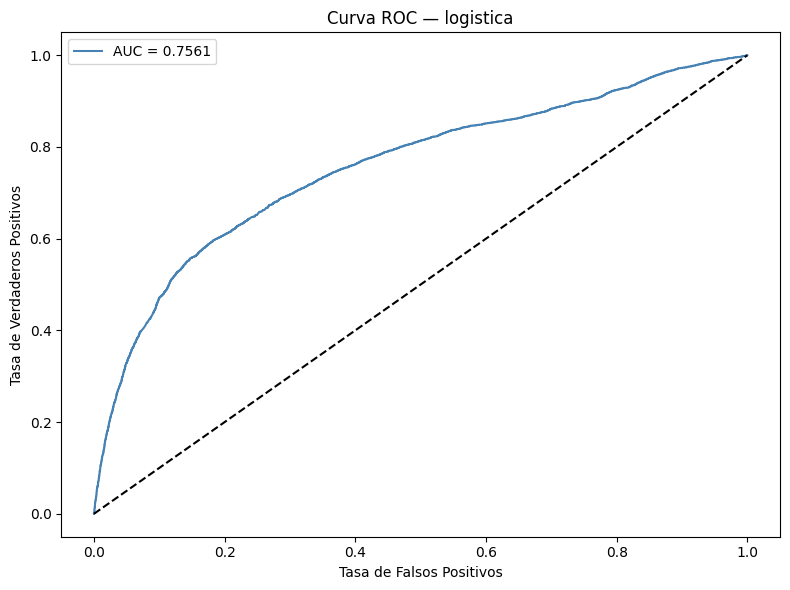

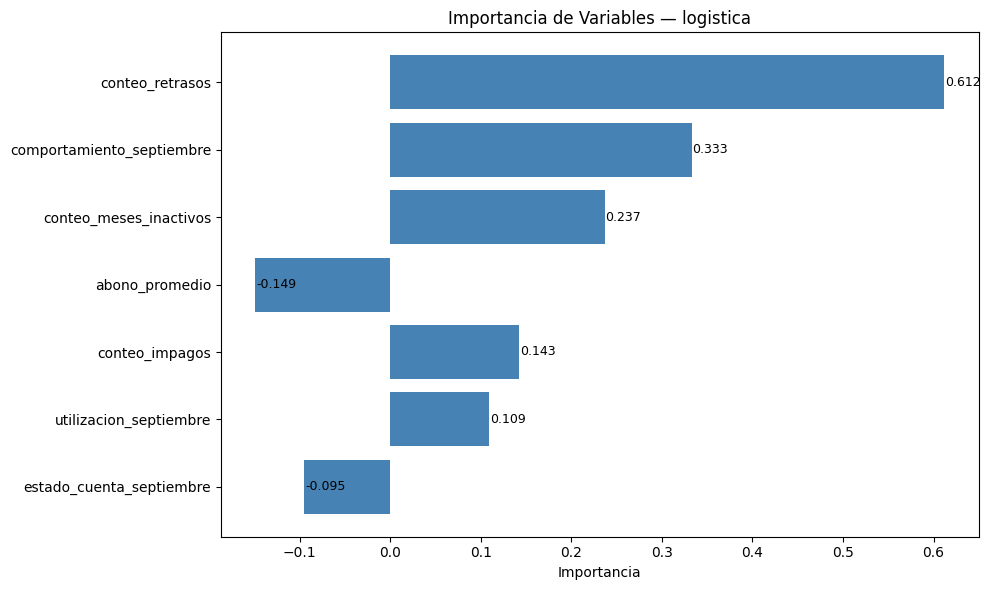


Modelo guardado como logistica.pkl ✅


In [4]:
from modelos import modelo_optimizado
modelo_optimizado(X, y, modelo='logistica');


Optimizando xgboost...


Best trial: 14. Best value: 0.787368: 100%|██████████| 30/30 [00:50<00:00,  1.69s/it]


Mejores parámetros  : {'n_estimators': 260, 'max_depth': 3, 'learning_rate': 0.03720181861619695, 'subsample': 0.7097939893129923, 'colsample_bytree': 0.9284982243094897}
Mejor AUC (inner CV): 0.7874

AUC-ROC : 0.7871
Gini    : 0.5742
KS      : 0.4332

Análisis de Thresholds:
 Threshold   TP    FP    TN   FN  Precision  Recall     F1
      0.20 4478 13087  3268  167     0.2549  0.9640 0.4032
      0.25 4336 11210  5145  309     0.2789  0.9335 0.4295
      0.30 4119  9410  6945  526     0.3045  0.8868 0.4533
      0.35 3859  7652  8703  786     0.3352  0.8308 0.4777
      0.40 3491  5646 10709 1154     0.3821  0.7516 0.5066
      0.45 3220  4274 12081 1425     0.4297  0.6932 0.5305
      0.50 2968  3377 12978 1677     0.4678  0.6390 0.5401
      0.55 2774  2713 13642 1871     0.5056  0.5972 0.5476
      0.60 2572  2202 14153 2073     0.5388  0.5537 0.5461
      0.65 2348  1732 14623 2297     0.5755  0.5055 0.5382
      0.70 2048  1239 15116 2597     0.6231  0.4409 0.5164
      0.75 1848

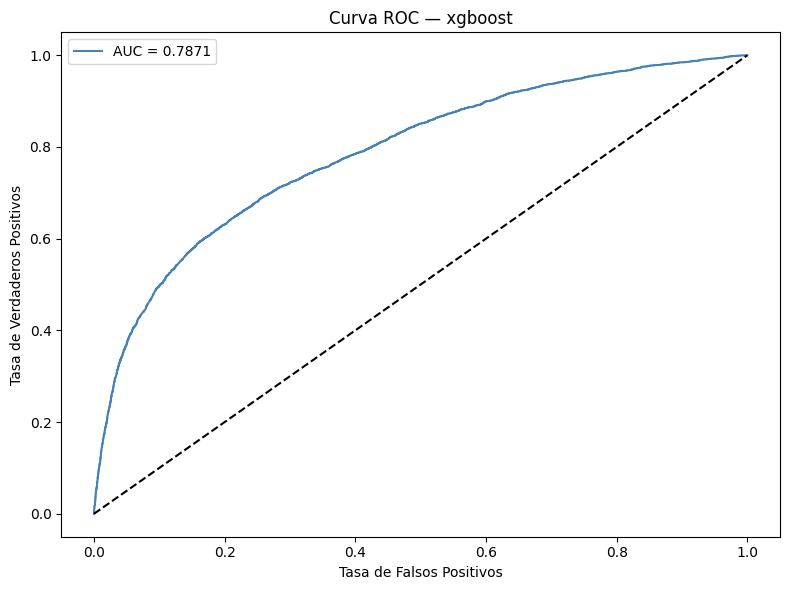

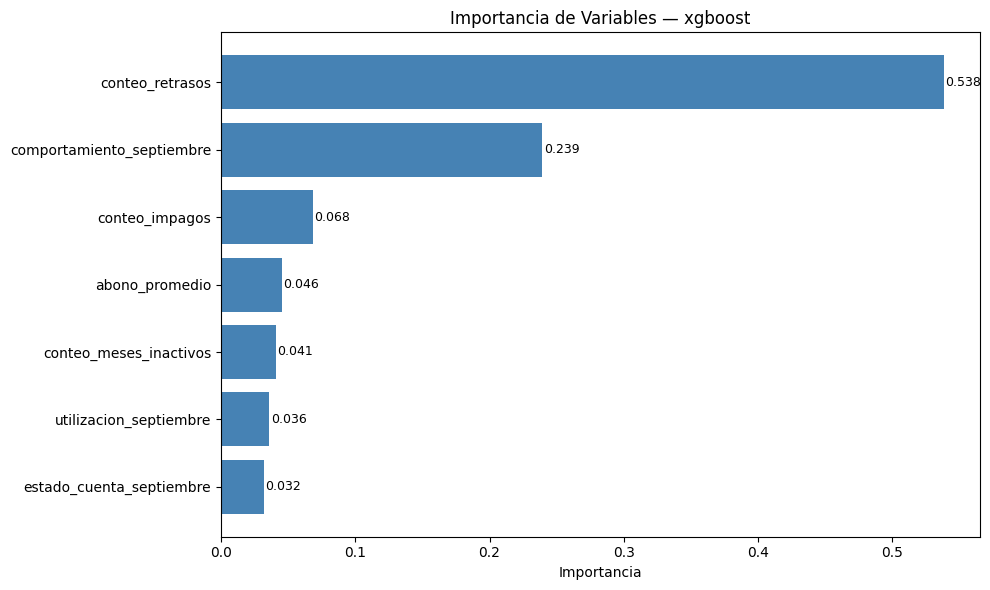


Modelo guardado como xgboost.pkl ✅


In [5]:
modelo_optimizado(X, y, modelo='xgboost');